# Tugas Klasifikasi Citra: Deteksi Jenis Sampah
## Menggunakan Transfer Learning (MobileNetV2) & Handling Overfitting

Tugas ini merupakan lanjutan dari pembuatan model CNN sebelumnya. Berdasarkan hasil evaluasi sebelumnya, model dasar mengalami **Overfitting** (akurasi data latih tinggi, tetapi akurasi validasi rendah dan loss validasi meningkat).

Oleh karena itu, pada program ini kita akan menerapkan:
1. **Transfer Learning** menggunakan arsitektur `MobileNetV2`.
2. **Pengecekan Overfitting** menggunakan plot grafik Loss dan Accuracy.
3. **Handling Overfitting** menggunakan gabungan teknik *Data Augmentation*, penambahan *Dropout*, dan *Early Stopping*.

In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Menghindari peringatan (warnings) agar tampilan rapi
tf.get_logger().setLevel('ERROR')

### 0. Eksplorasi Data & Visualisasi Gambar Sampah
Sebelum melatih model, mari kita lihat dulu distribusi jumlah gambar pada setiap kategori dan melihat contoh gambar dari dataset kita.

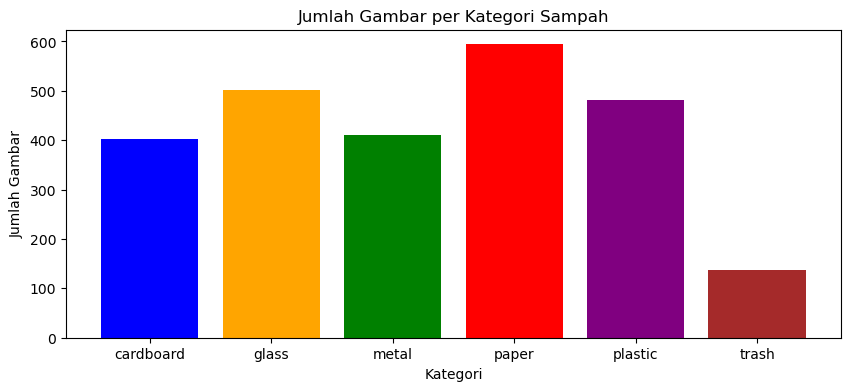

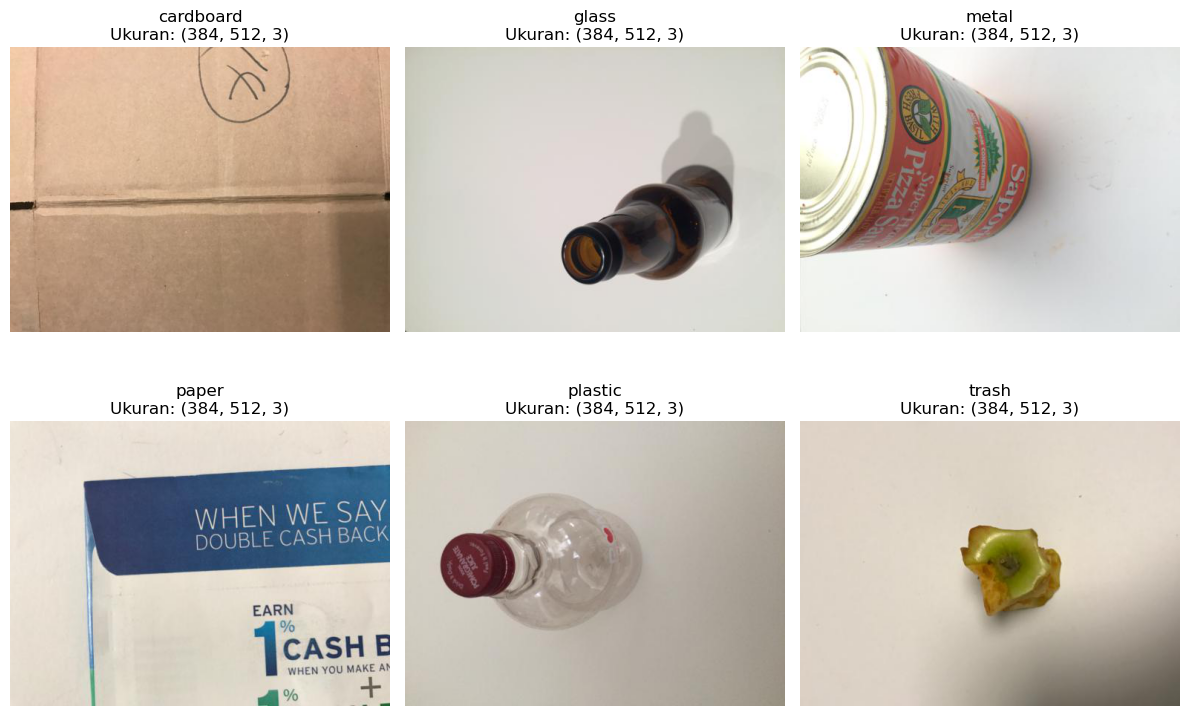

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_dir = 'TrashType_Image_Dataset'
kategori = sorted(os.listdir(dataset_dir))

# 1. Plot Bar Chart Distribusi Data
jumlah_data = [len(os.listdir(os.path.join(dataset_dir, kat))) for kat in kategori]

plt.figure(figsize=(10, 4))
plt.bar(kategori, jumlah_data, color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
plt.title('Jumlah Gambar per Kategori Sampah')
plt.ylabel('Jumlah Gambar')
plt.xlabel('Kategori')
plt.show()

# 2. Menampilkan Contoh Gambar dari setiap kategori
plt.figure(figsize=(12, 8))
for i, kat in enumerate(kategori):
    folder_path = os.path.join(dataset_dir, kat)
    contoh_gambar = os.listdir(folder_path)[0] # Ambil gambar pertama
    img_path = os.path.join(folder_path, contoh_gambar)
    
    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"{kat}\nUkuran: {img.shape}")
    plt.axis('off')
    
plt.tight_layout()
plt.show()

### 1. Data Preprocessing & Augmentation (Teknik Mencegah Overfitting)
Untuk mengatasi jumlah data yang terbatas, kita menggunakan `ImageDataGenerator`. Kita menambahkan augmentasi seperti rotasi, pergeseran, dan zoom. Hal ini akan memaksa model untuk belajar fitur sampah dari berbagai sudut, sehingga sangat efektif **mencegah overfitting**.

In [3]:
dataset_dir = 'TrashType_Image_Dataset'
img_size = (224, 224)
batch_size = 32

# Augmentasi Data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 20% data digunakan sebagai data validasi
)

print("Memuat Data Training:")
train_data = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

print("\nMemuat Data Validasi:")
val_data = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_data.class_indices.keys())
print(f"\nKategori Sampah: {class_names}")

Memuat Data Training:
Found 2024 images belonging to 6 classes.

Memuat Data Validasi:
Found 503 images belonging to 6 classes.

Kategori Sampah: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 2. Membangun Model Transfer Learning (MobileNetV2) & Dropout
Kita menggunakan `MobileNetV2` yang telah dilatih pada jutaan gambar. Kita akan "membekukan" (*freeze*) layer dasarnya agar bobot pengetahuannya tidak hilang. 

Selain itu, kita menambahkan layer **Dropout(0.5)** sebelum output. Dropout ini secara acak akan mematikan 50% saraf (neuron) saat berlatih. Ini adalah teknik ampuh kedua untuk **mengurangi overfitting**.

In [4]:
# 1. Load Base Model (MobileNetV2)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False  # Freeze (Bekukan) base model

# 2. Tambahkan Custom Layer di atasnya
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

# 3. Handling Overfitting: Dropout
x = Dropout(0.5)(x) 

# Output layer (6 kategori sampah)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

# 4. Gabungkan & Compile Model
model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 3. Pelatihan Model dengan Early Stopping
Teknik penanganan overfitting ketiga adalah **Early Stopping**. Kita memantau `val_loss`. Jika nilai kesalahan pada data validasi tidak membaik selama 5 putaran (epochs), pelatihan akan otomatis berhenti. Ini mencegah model "kebablasan" menghafal data.

In [5]:
# Handling Overfitting: Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

epochs = 20

# Proses Pelatihan (Training)
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.5637 - loss: 1.1629 - val_accuracy: 0.7157 - val_loss: 0.7776
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.7125 - loss: 0.7791 - val_accuracy: 0.7455 - val_loss: 0.6625
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7569 - loss: 0.6854 - val_accuracy: 0.7913 - val_loss: 0.6560
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 986ms/step - accuracy: 0.7885 - loss: 0.5966 - val_accuracy: 0.7634 - val_loss: 0.6988
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 977ms/step - accuracy: 0.7856 - loss: 0.5671 - val_accuracy: 0.7893 - val_loss: 0.6096
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8197 - loss: 0.4961 - val_accuracy: 0.7992 - val_loss: 0.6262
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8266 - loss: 0.4627 - val_accuracy: 0.7952 - val_loss: 0.5949
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8246 - loss: 0.4768 - val_accuracy: 0.7853 - val

### 4. Pengecekan Overfitting (Evaluasi Grafik)
Sekarang kita akan memplot grafik Akurasi dan Loss. 
Apabila garis *Training* dan garis *Validation* berjalan berdekatan, serta nilai *Validation Loss* tidak melonjak naik, maka dapat dipastikan **overfitting telah berhasil ditangani**.

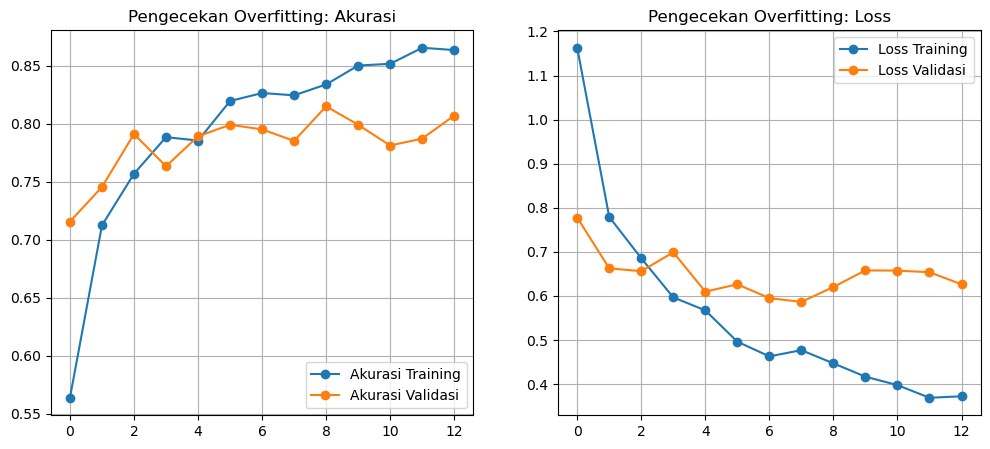

In [6]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Training', marker='o')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi', marker='o')
plt.legend(loc='lower right')
plt.title('Pengecekan Overfitting: Akurasi')
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Training', marker='o')
plt.plot(epochs_range, val_loss, label='Loss Validasi', marker='o')
plt.legend(loc='upper right')
plt.title('Pengecekan Overfitting: Loss')
plt.grid(True)

plt.show()